<a href="https://colab.research.google.com/github/rSith/machine-learning-specialization/blob/rSith-dev/ML_Specialization_02_Multiple_Variable_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Variable Linear Regression — Week 2


## 0. Tools and notation

| Symbol | Meaning | Python |
|---|---|---|
| $\mathbf{X}$ | training matrix, shape $(m, n)$ | `X_train` |
| $\mathbf{y}$ | targets, shape $(m,)$ | `y_train` |
| $\mathbf{x}^{(i)}$ | example $i$ (one row of $\mathbf{X}$) | `X_train[i]` |
| $x_j^{(i)}$ | feature $j$ of example $i$ | `X_train[i, j]` |
| $m$, $n$ | number of examples, number of features | `m, n = X.shape` |
| $\mathbf{w}$, $b$ | parameters: weights and bias | `w`, `b` |
| $\alpha$ | learning rate | `alpha` |


In [1]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)

## 1. Multiple linear regression

### 1.1 Small dataset

| Size (sqft) | Bedrooms | Floors | Age | Price ($1000s) |
|---|---|---|---|---|
| 2104 | 5 | 1 | 45 | 460 |
| 1416 | 3 | 2 | 40 | 232 |
| 852  | 2 | 1 | 35 | 178 |

In [2]:
X_small = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_small = np.array([460, 232, 178])
print(f"X shape: {X_small.shape}, y shape: {y_small.shape}")

# parameters close to the optimum (given in Lab 02)
b_init = 785.1811367994083
w_init = np.array([0.39133535, 18.75376741, -53.36032453, -26.42131618])

X shape: (3, 4), y shape: (3,)


### 1.2 Model: $f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b$

Both versions below give the same answer. The vectorized `np.dot` version is shorter and much faster.

In [3]:
def predict_single_loop(x, w, b):
    p = 0
    for j in range(x.shape[0]):
        p += x[j] * w[j]
    return p + b

def predict(x, w, b):
    return np.dot(x, w) + b

x_vec = X_small[0]
print(f"loop:       {predict_single_loop(x_vec, w_init, b_init)}")
print(f"vectorized: {predict(x_vec, w_init, b_init)}")

loop:       459.9999976194083
vectorized: 459.9999976194083


### 1.3 Cost function

$$J(\mathbf{w},b) = \frac{1}{2m}\sum_{i=0}^{m-1}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2$$

In [4]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    err = X @ w + b - y          # vectorized version of the loop in Lab 02
    return (err @ err) / (2 * m)

print(f"Cost at optimal w: {compute_cost(X_small, y_small, w_init, b_init)}")   # expected ≈ 1.5578904880036537e-12

Cost at optimal w: 1.5578904045996674e-12


### 1.4 Gradient

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i}\left(f(\mathbf{x}^{(i)}) - y^{(i)}\right)x_j^{(i)}, \qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i}\left(f(\mathbf{x}^{(i)}) - y^{(i)}\right)$$

The function returns `(dj_db, dj_dw)` in that order, as in the labs.

In [5]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    err = X @ w + b - y          # shape (m,)
    dj_dw = (X.T @ err) / m      # shape (n,)
    dj_db = np.sum(err) / m      # scalar
    return dj_db, dj_dw

dj_db, dj_dw = compute_gradient(X_small, y_small, w_init, b_init)
print(f"dj_db at initial w,b: {dj_db}")      # expected ≈ -1.67e-06
print(f"dj_dw at initial w,b: {dj_dw}")      # expected ≈ [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]

dj_db at initial w,b: -1.6739251122999121e-06
dj_dw at initial w,b: [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


### 1.5 Gradient descent

Repeat until convergence, updating **simultaneously**:

$$w_j := w_j - \alpha\frac{\partial J}{\partial w_j}, \qquad b := b - \alpha\frac{\partial J}{\partial b}$$



In [6]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, verbose=True):
    w = copy.deepcopy(w_in)      # don't change the caller's array
    b = b_in
    J_history = []
    print_every = max(1, math.ceil(num_iters / 10))
    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw    # FIXED (was: w = 2 - alpha * dj_dw)
        b = b - alpha * dj_db
        J_history.append(compute_cost(X, y, w, b))
        if verbose and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:5d}: Cost {J_history[-1]:10.2f}")
    return w, b, J_history

In [7]:
initial_w = np.zeros_like(w_init)
initial_b = 0.
w_final, b_final, J_hist = gradient_descent(X_small, y_small, initial_w, initial_b,
                                            alpha=5.0e-7, num_iters=1000)
print(f"\nb, w found by gradient descent: {b_final:0.2f}, {w_final}")
for i in range(X_small.shape[0]):
    print(f"prediction: {predict(X_small[i], w_final, b_final):0.2f}, target value: {y_small[i]}")

Iteration     0: Cost    2529.46
Iteration   100: Cost     695.99
Iteration   200: Cost     694.92
Iteration   300: Cost     693.86
Iteration   400: Cost     692.81
Iteration   500: Cost     691.77
Iteration   600: Cost     690.73
Iteration   700: Cost     689.71
Iteration   800: Cost     688.70
Iteration   900: Cost     687.69
Iteration   999: Cost     686.70

b, w found by gradient descent: -0.00, [ 0.2   0.   -0.01 -0.07]
prediction: 426.19, target value: 460
prediction: 286.17, target value: 232
prediction: 171.47, target value: 178


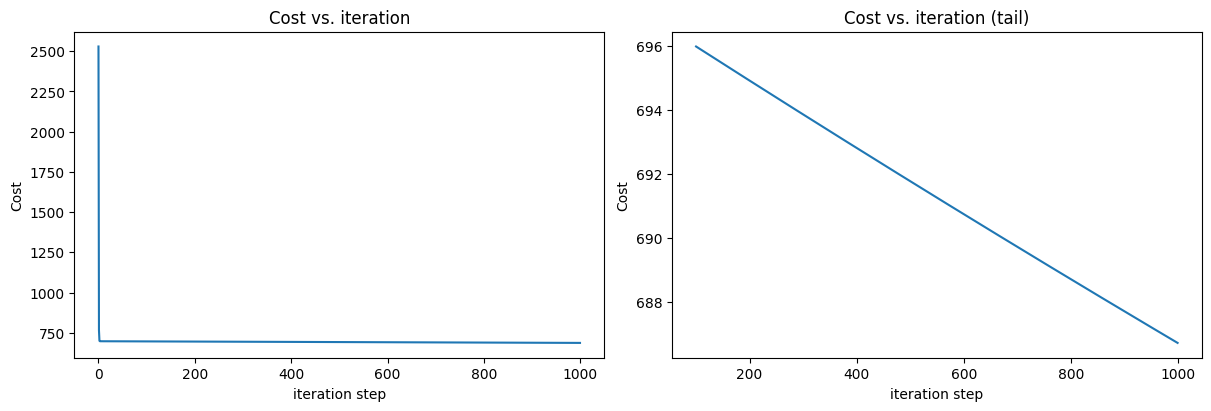

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost');               ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step');     ax2.set_xlabel('iteration step')
plt.show()

**Observation.** The cost falls smoothly, but the predictions (≈426, 286, 171) are still some way from the targets (460, 232, 178). The features have very different scales (size is about 1000× the number of floors), so one α cannot suit every weight. Part 2 fixes this.

## 2. Learning rate and feature scaling

### 2.1 Full housing dataset

Earlier versions used only 3 rows here. This part uses the full course dataset (`houses.txt`, 100 rows). It is embedded below so the notebook runs anywhere, and a local `houses.txt` is loaded if present.

In [9]:
import io, os
HOUSES_CSV = """
952,2,1,65,271.5
1244,3,1,64,300
1947,3,2,17,509.8
1725,3,2,42,394
1959,3,2,15,540
1314,2,1,14,415
864,2,1,66,230
1836,3,1,17,560
1026,3,1,43,294
3194,4,2,87,718.2
788,2,1,80,200
1200,2,2,17,302
1557,2,1,18,468
1430,3,1,20,374.2
1220,2,1,15,388
1092,2,1,64,282
848,1,1,17,311.8
1682,3,2,23,401
1768,3,2,18,449.8
1040,3,1,44,301
1652,2,1,21,502
1088,2,1,35,340
1316,3,1,14,400.282
1593,0,1,20,572
972,2,1,73,264
1097,3,1,37,304
1004,2,1,51,298
904,3,1,55,219.8
1694,3,1,13,490.7
1073,2,1,100,216.96
1419,3,2,19,368.2
1164,3,1,52,280
1935,3,2,12,526.87
1216,2,2,74,237
2482,4,2,16,562.426
1200,2,1,18,369.8
1840,3,2,20,460
1851,3,2,57,374
1660,3,2,19,390
1096,2,2,97,158
1775,3,2,28,426
2030,4,2,45,390
1784,4,2,107,277.774
1073,2,1,100,216.96
1552,3,1,16,425.8
1953,3,2,16,504
1224,2,2,12,329
1616,3,1,16,464
816,2,1,58,220
1349,3,1,21,358
1571,3,1,14,478
1486,3,1,57,334
1506,2,1,16,426.98
1097,3,1,27,290
1764,3,2,24,463
1208,2,1,14,390.8
1470,3,2,24,354
1768,3,2,84,350
1654,3,1,19,460
1029,3,1,60,237
1120,2,2,16,288.304
1150,3,1,62,282
816,2,1,39,249
1040,3,1,25,304
1392,3,1,64,332
1603,3,2,29,351.8
1215,3,1,63,310
1073,2,1,100,216.96
2599,4,2,22,666.336
1431,3,1,59,330
2090,3,2,26,480
1790,4,2,49,330.3
1484,3,2,16,348
1040,3,1,25,304
1431,3,1,22,384
1159,3,1,53,316
1547,3,2,12,430.4
1983,3,2,22,450
1056,3,1,53,284
1180,2,1,99,275
1358,2,1,17,414
960,3,1,51,258
1456,3,2,16,378
1446,3,2,25,350
1208,2,1,15,412
1553,3,2,16,373
882,3,1,49,225
2030,4,2,45,390
1040,3,1,62,267.4
1616,3,1,16,464
803,2,1,80,174
1430,3,2,21,340
1656,3,1,61,430
1541,3,1,16,440
948,3,1,53,216
1224,2,2,12,329
1432,2,1,43,388
1660,3,2,19,390
1212,3,1,20,356
1050,2,1,65,257.8
"""

def load_house_data():
    if os.path.exists("houses.txt"):
        data = np.loadtxt("houses.txt", delimiter=",")
    else:
        data = np.loadtxt(io.StringIO(HOUSES_CSV.strip()), delimiter=",")
    return data[:, :4], data[:, 4]

X_train, y_train = load_house_data()
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (100, 4), y_train shape: (100,)


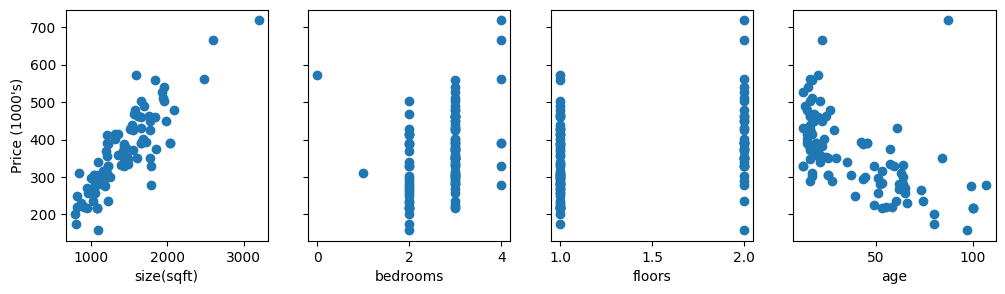

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

Size has the strongest (positive) effect on price. Bedrooms and floors have little effect, and older houses tend to be cheaper.

### 2.2 Choosing α

We try three learning rates on the **unscaled** data. The helper below also plots the path of $w_0$ against cost.

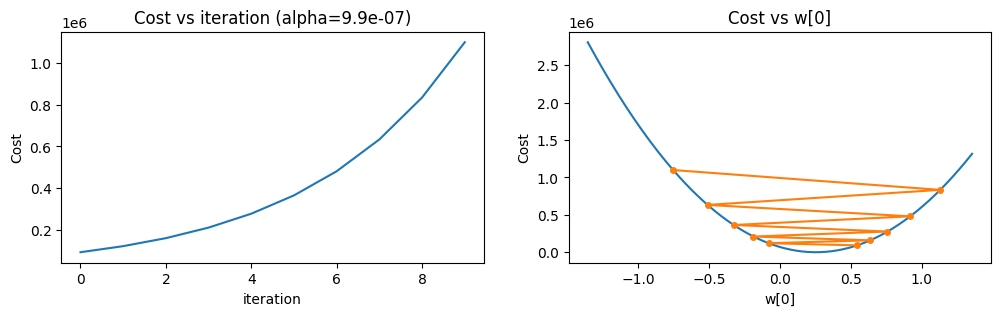

final cost after 10 iterations: 1.100e+06


In [11]:
def run_and_plot(alpha, iters=10):
    w, b, hist = [], [], []
    wi, bi = np.zeros(X_train.shape[1]), 0.
    for _ in range(iters):                     # keep w0 at every step for plotting
        dj_db, dj_dw = compute_gradient(X_train, y_train, wi, bi)
        wi = wi - alpha * dj_dw
        bi = bi - alpha * dj_db
        w.append(wi.copy()); hist.append(compute_cost(X_train, y_train, wi, bi))
    w = np.array(w)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(hist); ax[0].set_title(f"Cost vs iteration (alpha={alpha})")
    ax[0].set_xlabel("iteration"); ax[0].set_ylabel("Cost")
    # cost curve for w0 with the other parameters fixed at their final values
    w0_range = np.linspace(-max(abs(w[:, 0])) * 1.2, max(abs(w[:, 0])) * 1.2, 200)
    wf = wi.copy()
    costs = [compute_cost(X_train, y_train, np.r_[v, wf[1:]], bi) for v in w0_range]
    ax[1].plot(w0_range, costs, c="tab:blue")
    ax[1].plot(w[:, 0], hist, "-o", c="tab:orange", ms=4)
    ax[1].set_title("Cost vs w[0]"); ax[1].set_xlabel("w[0]"); ax[1].set_ylabel("Cost")
    plt.show()
    print(f"final cost after {iters} iterations: {hist[-1]:.3e}")

run_and_plot(9.9e-7)

**α = 9.9e-7 is too large:** the cost increases every step and $w_0$ swings further past the minimum each time.

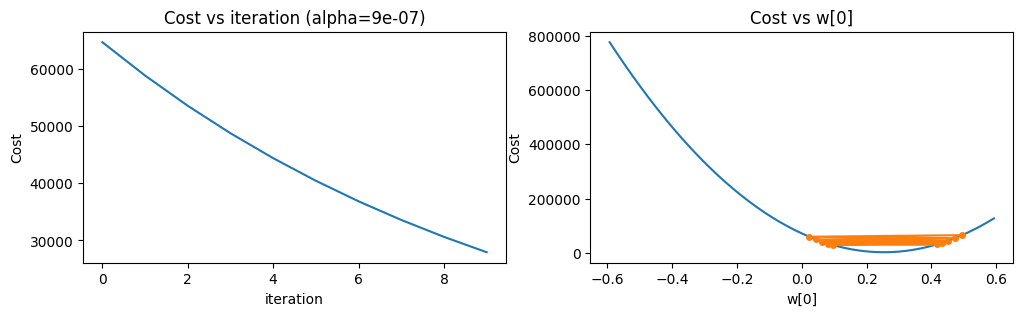

final cost after 10 iterations: 2.794e+04


In [12]:
run_and_plot(9e-7)

**α = 9e-7 is just below the limit:** the cost falls, but $w_0$ oscillates across the minimum before settling.

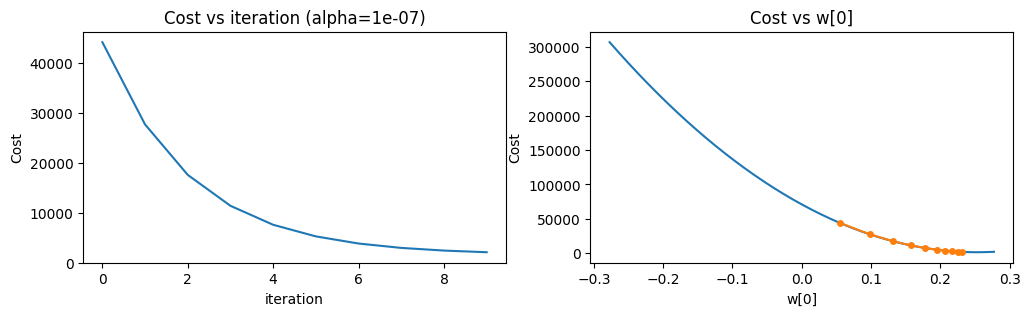

final cost after 10 iterations: 2.090e+03


In [13]:
run_and_plot(1e-7)

**α = 1e-7 works well:** the cost falls steadily and $w_0$ moves directly towards the minimum.

> Rule of thumb: try α values about 3× apart (0.001, 0.003, 0.01, …). Choose the largest one for which the cost still falls every iteration.

### 2.3 Why scale features?

Without scaling, **the weights update at very different rates**. The gradient for each $w_j$ is multiplied by $x_j$, so the weight for size (values in the thousands) takes much larger steps than the weight for floors (values 1–2). A single α is either too large for $w_0$ or too small for the rest.

Common methods:
- **Divide by max:** $x_j / \max(x_j)$ gives values in $[0, 1]$ for positive features
- **Mean normalization:** $(x_j - \mu_j)/(\max - \min)$ gives values in about $[-1, 1]$
- **Z-score normalization:** $(x_j - \mu_j)/\sigma_j$ gives mean 0 and standard deviation 1. This is used below.

(Note: z-scored values do **not** all fall inside $[-1, 1]$. About 68% do; the rest usually fall within ±3.)

In [14]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f"X_mu = {X_mu}, \nX_sigma = {X_sigma}")
print(f"Peak to Peak range by column in Raw        X: {np.ptp(X_train, axis=0)}")
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_norm, axis=0)}")

X_mu = [1.41e+03 2.71e+00 1.38e+00 3.86e+01], 
X_sigma = [412.17   0.65   0.49  25.79]
Peak to Peak range by column in Raw        X: [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized X: [5.84 6.13 2.06 3.68]


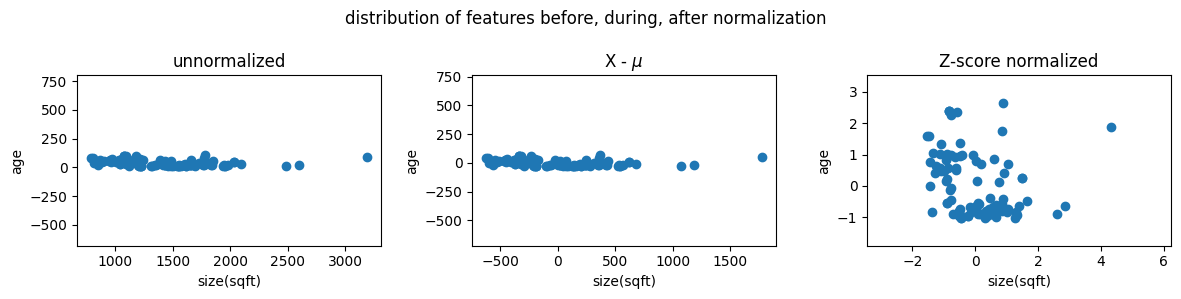

In [15]:
# step by step: original -> subtract mean -> divide by std (size vs age)
X_mean = X_train - X_mu
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, data, title in zip(ax, [X_train, X_mean, X_norm],
                          ["unnormalized", r"X - $\mu$", "Z-score normalized"]):
    a.scatter(data[:, 0], data[:, 3]); a.set_title(title)
    a.set_xlabel(X_features[0]); a.set_ylabel(X_features[3]); a.axis('equal')
fig.suptitle("distribution of features before, during, after normalization")
plt.tight_layout(); plt.show()

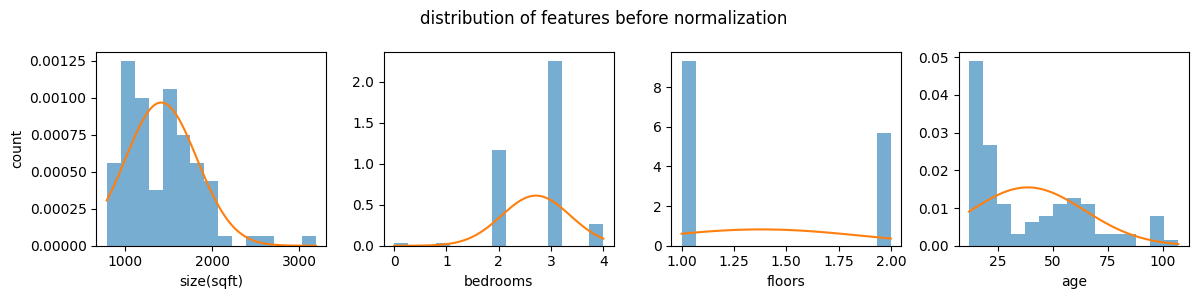

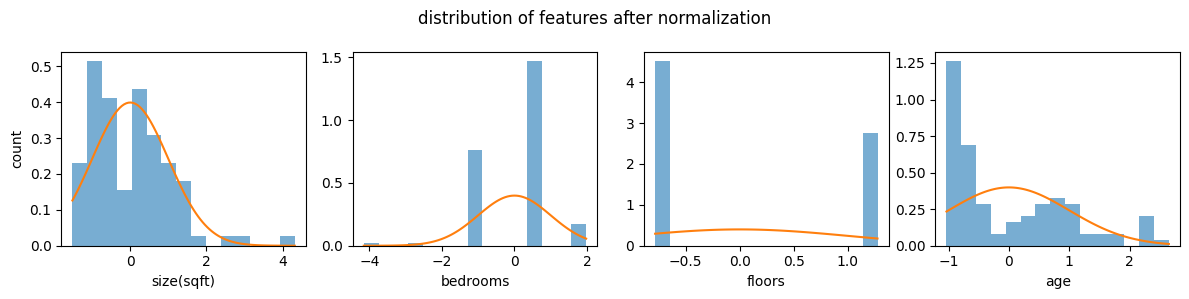

In [16]:
def norm_plot(ax, data):
    ax.hist(data, bins=15, density=True, alpha=0.6)
    mu, sd = np.mean(data), np.std(data)
    xs = np.linspace(data.min(), data.max(), 100)
    ax.plot(xs, np.exp(-0.5 * ((xs - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi)), c="tab:orange")

for title, data in [("before", X_train), ("after", X_norm)]:
    fig, ax = plt.subplots(1, 4, figsize=(12, 3))
    for i in range(4):
        norm_plot(ax[i], data[:, i]); ax[i].set_xlabel(X_features[i])
    ax[0].set_ylabel("count")
    fig.suptitle(f"distribution of features {title} normalization")
    plt.tight_layout(); plt.show()

### 2.4 Gradient descent on normalized data

With scaled features we can use a much larger learning rate (**α = 0.1**) and converge in about 1000 iterations.

In [17]:
w_norm, b_norm, hist_norm = gradient_descent(X_norm, y_train, np.zeros(4), 0., alpha=1.0e-1, num_iters=1000)
print(f"\nw = {w_norm}, b = {b_norm:0.2f}")       # lab (99-row copy) ≈ [110.56 -21.27 -32.71 -37.97], 363.16; this 100-row file gives very close values

Iteration     0: Cost   57326.42
Iteration   100: Cost     221.73
Iteration   200: Cost     219.71
Iteration   300: Cost     219.71
Iteration   400: Cost     219.71
Iteration   500: Cost     219.71
Iteration   600: Cost     219.71
Iteration   700: Cost     219.71
Iteration   800: Cost     219.71
Iteration   900: Cost     219.71
Iteration   999: Cost     219.71

w = [110.61 -21.47 -32.66 -37.78], b = 362.24


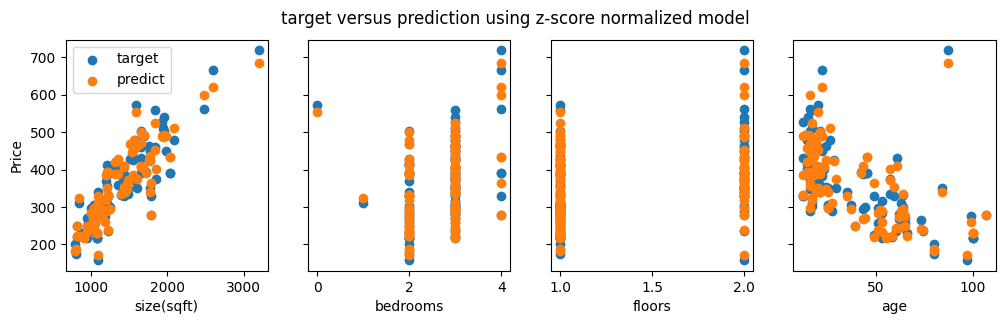

In [18]:
m = X_norm.shape[0]
yp = X_norm @ w_norm + b_norm
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(4):
    ax[i].scatter(X_train[:, i], y_train, label='target')
    ax[i].scatter(X_train[:, i], yp, color="tab:orange", label='predict')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price"); ax[0].legend()
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

### 2.5 Predicting a new house

A new example **must be normalized with the training** $\mu$ and $\sigma$. Do not normalize it on its own.

In [19]:
x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma
print(x_house_norm)
x_house_predict = np.dot(x_house_norm, w_norm) + b_norm
print(f"predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = ${x_house_predict*1000:0.0f}")

[-0.52  0.44 -0.78  0.05]
predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = $318936


### 2.6 Cost contours: why scaling helps

We plot the cost over $(w_0, w_1)$ with the other parameters fixed. Unscaled data gives long, thin ellipses, so gradient descent zig-zags. Scaled data gives nearly circular contours, so it moves straight to the minimum.

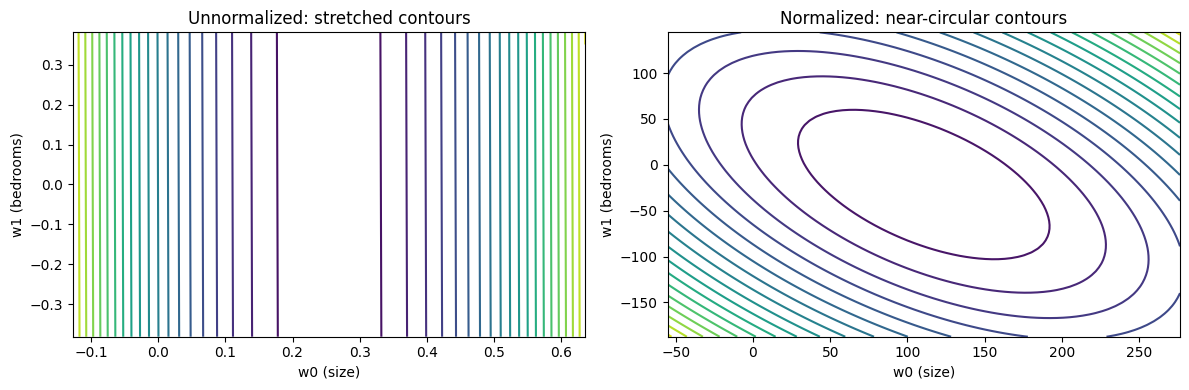

In [20]:
def contour_w0_w1(ax, X, y, w_ref, b_ref, title):
    r0 = max(abs(w_ref[0]), 1e-3) * 1.5
    r1 = max(abs(w_ref[1]), abs(w_ref[0])) * 1.5
    w0s, w1s = np.meshgrid(np.linspace(w_ref[0] - r0, w_ref[0] + r0, 80),
                           np.linspace(w_ref[1] - r1, w_ref[1] + r1, 80))
    Z = np.zeros_like(w0s)
    for i in range(w0s.shape[0]):
        for j in range(w0s.shape[1]):
            w = w_ref.copy(); w[0], w[1] = w0s[i, j], w1s[i, j]
            Z[i, j] = compute_cost(X, y, w, b_ref)
    ax.contour(w0s, w1s, Z, levels=20, cmap="viridis")
    ax.set_xlabel("w0 (size)"); ax.set_ylabel("w1 (bedrooms)"); ax.set_title(title)

w_raw, b_raw, _ = gradient_descent(X_train, y_train, np.zeros(4), 0., 1e-7, 1000, verbose=False)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
contour_w0_w1(ax[0], X_train, y_train, w_raw, b_raw, "Unnormalized: stretched contours")
contour_w0_w1(ax[1], X_norm,  y_train, w_norm, b_norm, "Normalized: near-circular contours")
plt.tight_layout(); plt.show()

## 3. Feature engineering and polynomial regression

Linear regression can fit **non-linear** curves when we add engineered features such as $x^2$ and $x^3$. The model is still linear in its parameters $\mathbf{w}$.

### 3.1 No feature engineering

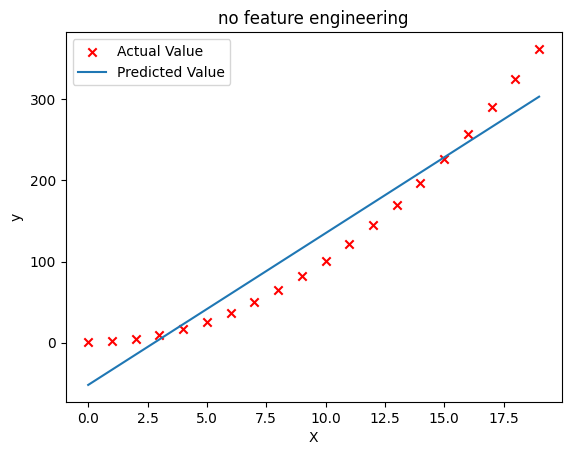

In [21]:
x = np.arange(0, 20, 1)
y = 1 + x**2
X = x.reshape(-1, 1)
model_w, model_b, _ = gradient_descent(X, y, np.zeros(1), 0., alpha=1e-2, num_iters=1000, verbose=False)
plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("no feature engineering")
plt.plot(x, X @ model_w + model_b, label="Predicted Value"); plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.show()

A straight line cannot fit $y = 1 + x^2$.

### 3.2 Add $x^2$

Iteration     0: Cost    7329.22
Iteration  1000: Cost       0.22
Iteration  2000: Cost       0.22
Iteration  3000: Cost       0.22
Iteration  4000: Cost       0.22
Iteration  5000: Cost       0.22
Iteration  6000: Cost       0.21
Iteration  7000: Cost       0.21
Iteration  8000: Cost       0.21
Iteration  9000: Cost       0.21
Iteration  9999: Cost       0.21
w,b found by gradient descent: w: [1.], b: 0.0490


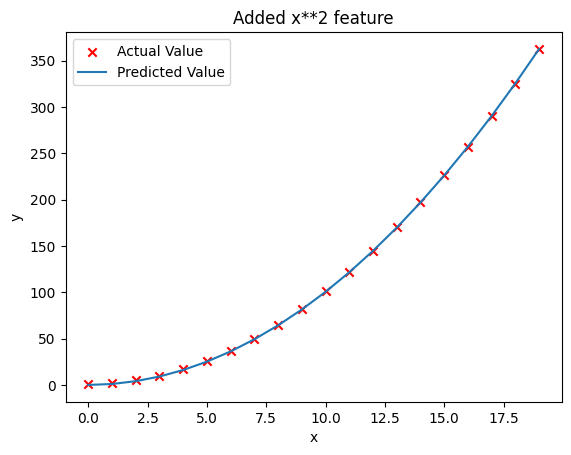

In [22]:
X = x**2
X = X.reshape(-1, 1)
model_w, model_b, _ = gradient_descent(X, y, np.zeros(1), 0., alpha=1e-5, num_iters=10000)
print(f"w,b found by gradient descent: w: {model_w}, b: {model_b:0.4f}")   # ≈ w=[1.], b≈0.05 (true: 1, 1)
plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Added x**2 feature")
plt.plot(x, X @ model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

### 3.3 Let gradient descent pick features: $x, x^2, x^3$

w,b found by gradient descent: w: [0.08 0.55 0.03], b: 0.0110


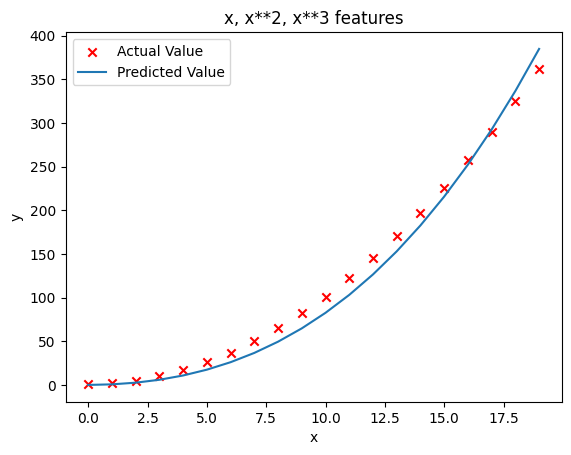

In [23]:
X = np.c_[x, x**2, x**3]
model_w, model_b, _ = gradient_descent(X, y, np.zeros(3), 0., alpha=1e-7, num_iters=10000, verbose=False)
print(f"w,b found by gradient descent: w: {model_w}, b: {model_b:0.4f}")
plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("x, x**2, x**3 features")
plt.plot(x, X @ model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

The weight on $x^2$ is the largest, so gradient descent has "chosen" the $x^2$ feature. After enough iterations the other weights would shrink towards 0.

### 3.4 An alternate view

For the model to fit well, the target should be linear in the **best feature**. Plotting $y$ against each engineered feature shows this.

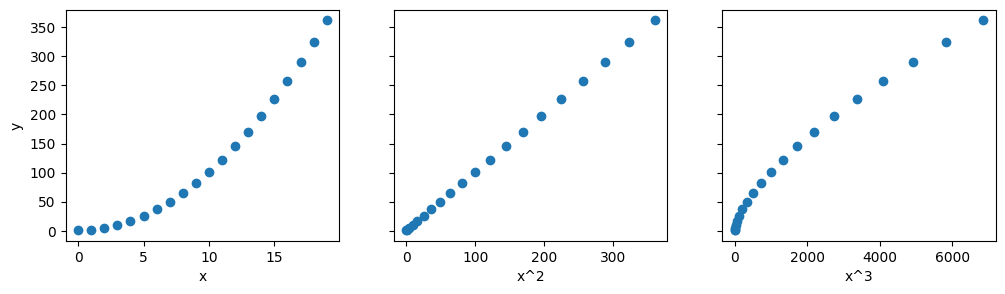

In [24]:
X_features_poly = ['x', 'x^2', 'x^3']
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:, i], y); ax[i].set_xlabel(X_features_poly[i])
ax[0].set_ylabel("y")
plt.show()

Only $y$ vs $x^2$ is a straight line, so $x^2$ is the feature that gives a linear model.

### 3.5 Scaling polynomial features

In [25]:
print(f"Peak to Peak range by column in Raw        X: {np.ptp(X, axis=0)}")
X_poly_norm, _, _ = zscore_normalize_features(X)
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_poly_norm, axis=0)}")

Peak to Peak range by column in Raw        X: [  19  361 6859]
Peak to Peak range by column in Normalized X: [3.3  3.18 3.28]


The raw ranges differ by a factor of about 400 (19 vs 6859). After scaling, all features have similar ranges, so a much larger **α = 0.1** is safe.

w,b found by gradient descent (normalized): w: [5.27e-05 1.13e+02 8.43e-05], b: 124.5000


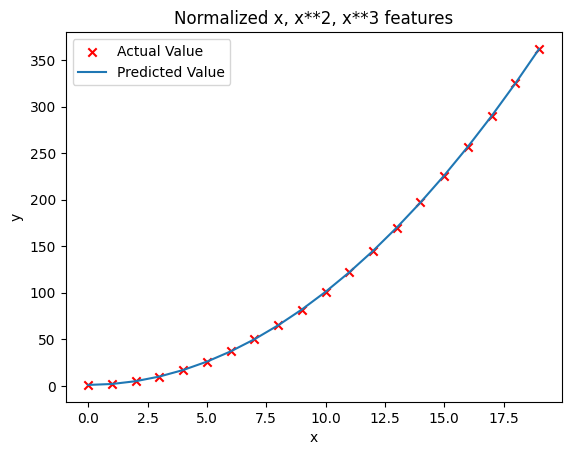

In [26]:
model_w, model_b, _ = gradient_descent(X_poly_norm, y, np.zeros(3), 0., alpha=1e-1, num_iters=100000, verbose=False)
print(f"w,b found by gradient descent (normalized): w: {model_w}, b: {model_b:0.4f}")
plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x, x**2, x**3 features")
plt.plot(x, X_poly_norm @ model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

### 3.6 Complex functions: $y = \cos(x/2)$ with features up to $x^{13}$

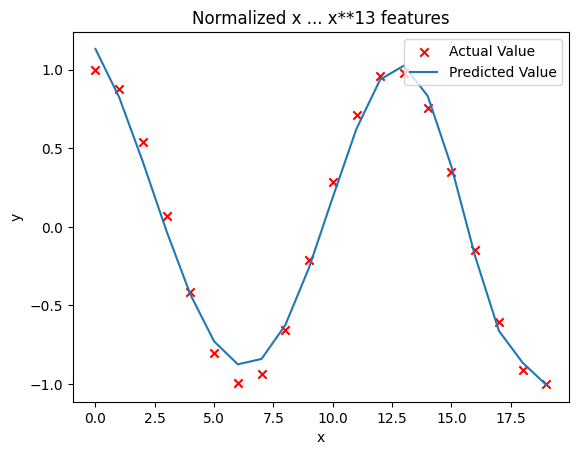

In [27]:
x = np.arange(0, 20, 1)
y = np.cos(x / 2)
X = np.c_[x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12, x**13]
X, _, _ = zscore_normalize_features(X)
model_w, model_b, _ = gradient_descent(X, y, np.zeros(X.shape[1]), 0., alpha=1e-1, num_iters=1000000, verbose=False)
plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Normalized x ... x**13 features")
plt.plot(x, X @ model_w + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

## 4. Linear regression with scikit-learn

- `StandardScaler` does z-score normalization, like our `zscore_normalize_features`.
- `SGDRegressor` does linear regression with **stochastic** gradient descent. It updates on one example at a time, so its answer is close to our batch result but not identical.

In [28]:

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_norm_sk = scaler.fit_transform(X_train)
print(f"Peak to Peak range by column in Raw        X: {np.ptp(X_train, axis=0)}")
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_norm_sk, axis=0)}")
print(f"StandardScaler matches our z-score: {np.allclose(X_norm_sk, X_norm)}")

Peak to Peak range by column in Raw        X: [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized X: [5.84 6.13 2.06 3.68]
StandardScaler matches our z-score: True


In [29]:
sgdr = SGDRegressor(max_iter=1000, random_state=0)
sgdr.fit(X_norm_sk, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

b_sk, w_sk = sgdr.intercept_, sgdr.coef_
print(f"sklearn  parameters: w: {w_sk}, b: {b_sk}")
print(f"our GD   parameters: w: {w_norm}, b: {b_norm:0.2f}")

SGDRegressor(random_state=0)
number of iterations completed: 131, number of weight updates: 13101.0
sklearn  parameters: w: [110.31 -21.28 -32.46 -37.84], b: [362.25]
our GD   parameters: w: [110.61 -21.47 -32.66 -37.78], b: 362.24


In [30]:
y_pred_sgd = sgdr.predict(X_norm_sk)
y_pred = np.dot(X_norm_sk, w_sk) + b_sk
print(f"prediction using np.dot() and sgdr.predict match: {np.allclose(y_pred, y_pred_sgd)}")
print(f"Prediction on training set:\n{y_pred[:4]}")
print(f"Target values \n{y_train[:4]}")

# the same new house, using the scaler fitted on the training set
print(f"\nsklearn prediction for 1200 sqft/3 bed/1 floor/40 yrs: "
      f"${sgdr.predict(scaler.transform([[1200, 3, 1, 40]]))[0]*1000:0.0f}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[248.58 295.58 485.84 389.74]
Target values 
[271.5 300.  509.8 394. ]

sklearn prediction for 1200 sqft/3 bed/1 floor/40 yrs: $319028


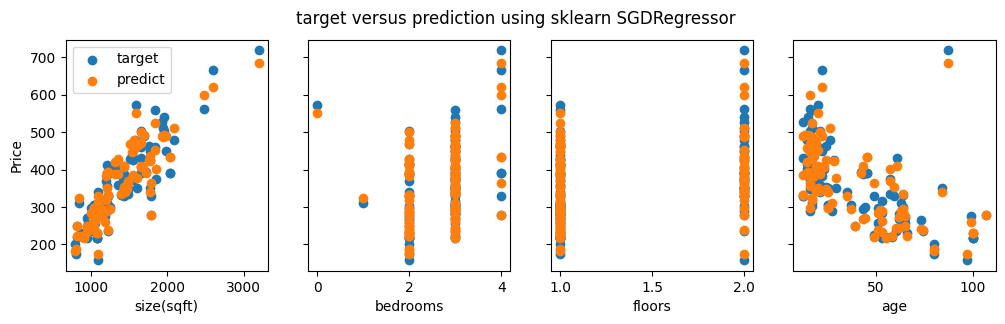

In [31]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train, label='target')
    ax[i].scatter(X_train[:, i], y_pred, color="tab:orange", label='predict')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price"); ax[0].legend()
fig.suptitle("target versus prediction using sklearn SGDRegressor")
plt.show()

## 5. Key takeaways

**Key takeaways:**
- Vectorization (`X @ w`) is shorter, faster and less error-prone than explicit loops.
- Choose α by trying values about 3× apart and checking that $J$ falls on every iteration.
- Feature scaling makes the cost contours near-circular, which allows a much larger α and faster convergence.
- Feature engineering lets a linear model fit curves, and gradient descent gives the largest weights to the most useful features.
- scikit-learn (`StandardScaler` + `SGDRegressor`) reproduces the manual pipeline in a few lines.